# Top 100 Cities of the World by Population (2026)

In [2]:
import pandas as pd
import matplotlib as plt
import numpy as np
import seaborn as sns

In [18]:
df = pd.read_csv(r"C:\Users\jyoti\Documents\DA Course FB\Excel\Files\Top 100 Worlds Largest Cities.csv")

### Basic Descriptive Statistics and Info

In [19]:
df.head()

,Rank,City,Country,Population (Est.),Area (sq km)
0,1,Tokyo,Japan,"37,115,000","8,231"
1,2,Delhi,India,"35,500,000","2,344"
2,3,Shanghai,China,"31,050,000","4,333"
3,4,Dhaka,Bangladesh,"25,360,000","2,570"
4,5,Sao Paulo,Brazil,"23,170,000","3,649"


In [20]:
df.shape

(100, 5)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Rank               100 non-null    int64 
 1   City               100 non-null    object
 2   Country            100 non-null    object
 3   Population (Est.)  100 non-null    object
 4   Area (sq km)       100 non-null    object
dtypes: int64(1), object(4)
memory usage: 4.0+ KB


In [22]:
df.describe()

,Rank
count,100.000000
mean,50.500000
std,29.011492
min,1.000000
25%,25.750000
50%,50.500000
75%,75.250000
max,100.000000


In [23]:
# name of the columns
df.columns

Index(['Rank', 'City', 'Country', 'Population (Est.)', 'Area (sq km)'], dtype='object')

### Data Cleaning

#### 1. Converting Population to numeric for Easy Analysis

In [24]:
df['Population (Est.)'] = df['Population (Est.)'].str.replace(",","")

In [27]:
df.head()

,Rank,City,Country,Population (Est.),Area (sq km)
0,1,Tokyo,Japan,37115000,"8,231"
1,2,Delhi,India,35500000,"2,344"
2,3,Shanghai,China,31050000,"4,333"
3,4,Dhaka,Bangladesh,25360000,"2,570"
4,5,Sao Paulo,Brazil,23170000,"3,649"


In [26]:
df['Population (Est.)'] = pd.to_numeric(df['Population (Est.)'], errors = 'coerce')

In [29]:
df.dtypes

Rank                  int64
City                 object
Country              object
Population (Est.)     int64
Area (sq km)         object
dtype: object

#### 2. Checking for Missing Values

In [16]:
df.isnull().sum()

Rank                 0
City                 0
Country              0
Population (Est.)    0
Area (sq km)         0
dtype: int64

In [30]:
# dropping duplicates if any exist
df.drop_duplicates()

,Rank,City,Country,Population (Est.),Area (sq km)
0,1,Tokyo,Japan,37115000,"8,231"
1,2,Delhi,India,35500000,"2,344"
2,3,Shanghai,China,31050000,"4,333"
3,4,Dhaka,Bangladesh,25360000,"2,570"
4,5,Sao Paulo,Brazil,23170000,"3,649"
...,...,...,...,...,...
95,96,Taipei,Taiwan,4520000,271
96,97,Pyongyang,North Korea,4490000,"3,194"
97,98,Dakar,Senegal,4460000,550
98,99,Baku,Azerbaijan,4410000,"2,130"


 **Now that our data is clean, we are ready to perform exploratory data analysis.**

### Univariate Analysis

*The simplest form of data analysis, focusing on analyzing only one variable at a time to describe its distribution, central tendency, and spread.*

In [34]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Frequency')

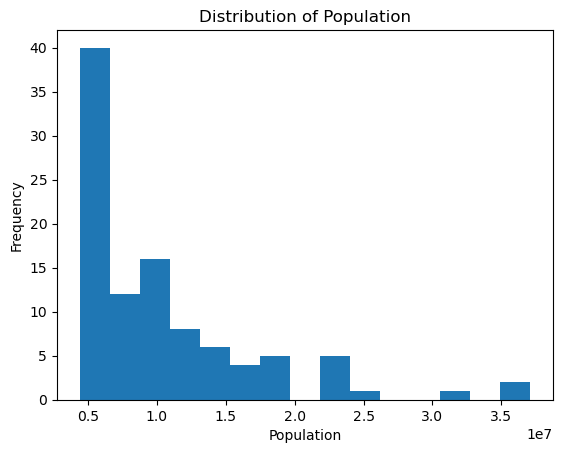

In [35]:
plt.hist(df['Population (Est.)'], bins = 15)
plt.title("Distribution of Population")
plt.xlabel("Population")
plt.ylabel("Frequency")

**The histogram is clearly left-skewed, there are a few outliers on the right which show that there is a major gap between top few cities with the highest population and the other cities.**

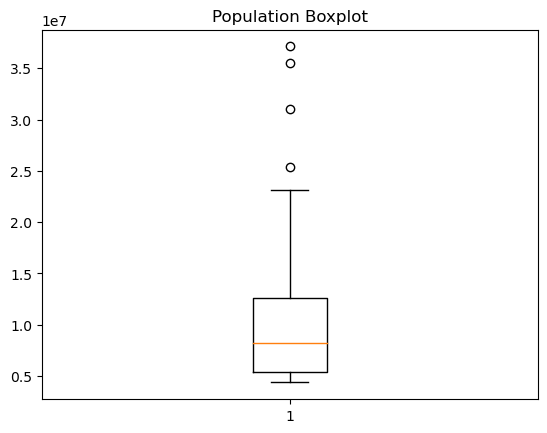

In [36]:
plt.boxplot(df['Population (Est.)'])
plt.title("Population Boxplot")
plt.show()

**As the boxplot shows, there are four cities with higher population that are outliers.**

### Top 10 Most Populated Cities

In [37]:
df.sort_values('Population (Est.)',ascending = False).head(10)

,Rank,City,Country,Population (Est.),Area (sq km)
0,1,Tokyo,Japan,37115000,"8,231"
1,2,Delhi,India,35500000,"2,344"
2,3,Shanghai,China,31050000,"4,333"
3,4,Dhaka,Bangladesh,25360000,"2,570"
4,5,Sao Paulo,Brazil,23170000,"3,649"
5,6,Cairo,Egypt,23075000,"2,010"
6,7,Mexico City,Mexico,23015000,"2,530"
7,8,Beijing,China,22980000,"4,284"
8,9,Mumbai,India,22540000,976
9,10,Osaka,Japan,18870000,"3,020"


Text(0, 0.5, 'Population')

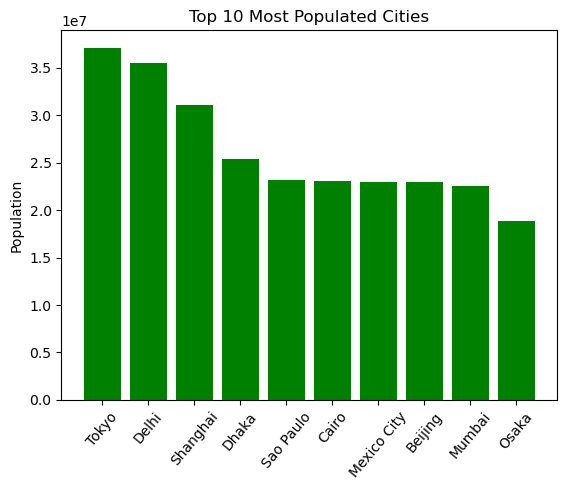

In [45]:
top10 = df.sort_values('Population (Est.)',ascending = False).head(10)

plt.bar(top10['City'], top10['Population (Est.)'], color = "green")
plt.title("Top 10 Most Populated Cities")
plt.xticks(rotation = 50)
plt.ylabel("Population")

### Bottom 10

In [39]:
df.sort_values('Population (Est.)').head(10)

,Rank,City,Country,Population (Est.),Area (sq km)
99,100,İzmir,Turkey,4380000,850
98,99,Baku,Azerbaijan,4410000,"2,130"
97,98,Dakar,Senegal,4460000,550
96,97,Pyongyang,North Korea,4490000,"3,194"
95,96,Taipei,Taiwan,4520000,271
94,95,Dubai,UAE,4580000,"1,610"
93,94,Medellin,Colombia,4650000,380
92,93,Kuwait City,Kuwait,4680000,200
91,92,Lucknow,India,4760000,"2,528"
90,91,Rome,Italy,4820000,"1,285"


## Country-Level Analysis

### Cities Per Country

In [48]:
df['Country'].value_counts()

Country
China           21
India           11
Brazil           4
Japan            3
Mexico           3
Pakistan         3
Turkey           3
Russia           2
Australia        2
South Korea      2
Indonesia        2
Colombia         2
Spain            2
Bangladesh       2
Egypt            2
UAE              1
Morocco          1
Canada           1
Ivory Coast      1
Ethiopia         1
Singapore        1
Myanmar          1
Ghana            1
Taiwan           1
Senegal          1
Germany          1
Algeria          1
Afghanistan      1
Italy            1
South Africa     1
North Korea      1
Kuwait           1
Tanzania         1
Sudan            1
Chile            1
DR Congo         1
Nigeria          1
Argentina        1
Philippines      1
Peru             1
Thailand         1
France           1
Angola           1
Vietnam          1
UK               1
Iran             1
Malaysia         1
Iraq             1
USA              1
Saudi Arabia     1
Azerbaijan       1
Name: count, dtype: int

**China and India clearly dominate this dataset**

### Average Population Per Country

In [50]:
df.groupby('Country')['Population (Est.)'].mean().sort_values(ascending = False)

Country
Japan           2.183167e+07
DR Congo        1.855000e+07
Nigeria         1.780000e+07
Argentina       1.589000e+07
Philippines     1.553000e+07
Bangladesh      1.533500e+07
Egypt           1.436250e+07
India           1.353045e+07
Pakistan        1.288333e+07
Brazil          1.218750e+07
Peru            1.167000e+07
Thailand        1.154000e+07
France          1.142000e+07
China           1.128881e+07
Mexico          1.118167e+07
Angola          1.042000e+07
Vietnam         1.006500e+07
UK              9.930000e+06
Iran            9.840000e+06
Russia          9.180000e+06
Malaysia        9.175000e+06
Tanzania        8.975000e+06
Turkey          8.733333e+06
Indonesia       8.515000e+06
Iraq            8.370000e+06
USA             8.345000e+06
Colombia        8.285000e+06
Saudi Arabia    8.080000e+06
South Korea     7.530000e+06
Chile           7.050000e+06
Sudan           6.980000e+06
South Africa    6.560000e+06
Canada          6.550000e+06
Spain           6.287500e+06
Ivory 

## Pareto Analysis

*A decision-making technique based on the 80/20 rule, which states that roughly 80% of problems (effects) result from 20% of causes.*

In [52]:
df = df.sort_values(by = 'Population (Est.)', ascending = False)

In [54]:
total_population = df['Population (Est.)'].sum()

In [55]:
total_population

1042870000

In [56]:
df['Cumulative_Population'] = df['Population (Est.)'].cumsum()

In [57]:
df['Cumulative_Percentage'] = (df['Cumulative_Population'] / total_population) * 100

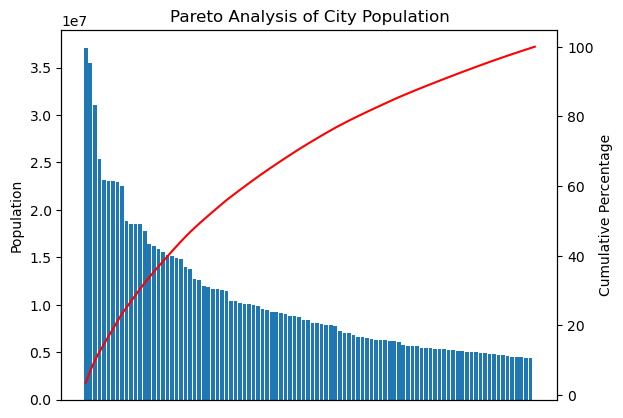

In [58]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Bar plot (Population)
ax1.bar(df['City'], df['Population (Est.)'])
ax1.set_xticks([])
ax1.set_ylabel('Population')

# Line plot (Cumulative %)
ax2 = ax1.twinx()
ax2.plot(df['Cumulative_Percentage'], color='red')
ax2.set_ylabel('Cumulative Percentage')

plt.title('Pareto Analysis of City Population')
plt.show()

In [59]:
df[df['Cumulative_Percentage'] <= 80]

,Rank,City,Country,Population (Est.),Area (sq km),Cumulative_Population,Cumulative_Percentage
0,1,Tokyo,Japan,37115000,"8,231",37115000,3.558929
1,2,Delhi,India,35500000,"2,344",72615000,6.962996
2,3,Shanghai,China,31050000,"4,333",103665000,9.940357
3,4,Dhaka,Bangladesh,25360000,"2,570",129025000,12.372108
4,5,Sao Paulo,Brazil,23170000,"3,649",152195000,14.593861
5,6,Cairo,Egypt,23075000,"2,010",175270000,16.806505
6,7,Mexico City,Mexico,23015000,"2,530",198285000,19.013396
7,8,Beijing,China,22980000,"4,284",221265000,21.216930
8,9,Mumbai,India,22540000,976,243805000,23.378273
9,10,Osaka,Japan,18870000,"3,020",262675000,25.187703
